# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [3]:
import pandas as pd
import sklearn

![Iris Flowers](../assets/iris_flowers.png)

### Step 1.a Load the data

In [4]:
iris = sklearn.datasets.load_iris(as_frame=True)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [5]:
x = iris.data
y = iris.target

### Step 2.b print the type of each

In [6]:
print(x.dtypes)
print(y.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object
int64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [7]:
import numpy as np  
print("Unique values:", np.unique(y))
print("Number of unique values:", len(np.unique(y)))

Unique values: [0 1 2]
Number of unique values: 3


the task is classification, the target is catigorical

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
print("Data matrix shape:", x.shape)
print("Target shape:", y.shape)
print("Number of samples:", x.shape[0])
print("Number of columns:", x.shape[1])

Data matrix shape: (150, 4)
Target shape: (150,)
Number of samples: 150
Number of columns: 4


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [12]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

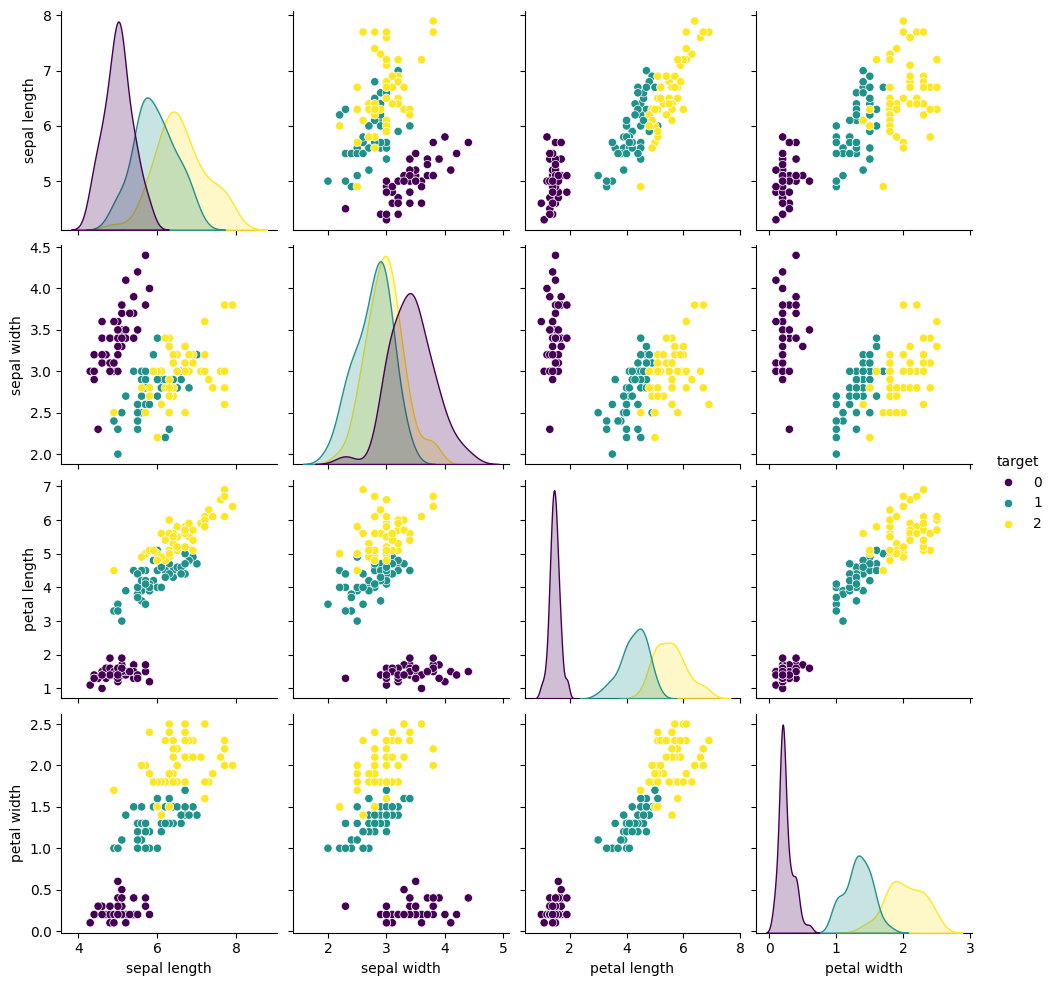

In [17]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data
y = iris.target

# Rebuild df fresh
df = pd.DataFrame(x, columns=["sepal length", "sepal width", "petal length", "petal width"])
df["target"] = y

sns.pairplot(df, hue="target", palette="viridis")
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [18]:
x1 = x[:, 0:2]  # columns 0 and 1
print("x1 shape:", x1.shape)

x1 shape: (150, 2)


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [19]:
x2 = x[:, 2:4]  # columns 2 and 3
print("x2 shape:", x2.shape)

x2 shape: (150, 2)


### Step 7. Initialize 2 `LogisticRegression` models

In [20]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()  # will train on x1 (sepal)
model2 = LogisticRegression()  # will train on x2 (petal)

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [21]:
from sklearn.model_selection import train_test_split

x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y, test_size=0.2, random_state=42, stratify=y)
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y, test_size=0.2, random_state=42, stratify=y)

print("x1 train/test:", x1_train.shape, x1_test.shape)
print("x2 train/test:", x2_train.shape, x2_test.shape)

x1 train/test: (120, 2) (30, 2)
x2 train/test: (120, 2) (30, 2)


### Step 9.a Train both models

In [22]:
model1.fit(x1_train, y1_train)
model2.fit(x2_train, y2_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 10. Evaluate and compare both models

In [23]:
from sklearn.metrics import accuracy_score

score1 = accuracy_score(y1_test, model1.predict(x1_test))
score2 = accuracy_score(y2_test, model2.predict(x2_test))

print(f"Model 1 (sepal features) accuracy:  {score1:.4f}")
print(f"Model 2 (petal features) accuracy:  {score2:.4f}")

if score2 > score1:
    print("→ Model 2 (petal) performs better")
else:
    print("→ Model 1 (sepal) performs better")

Model 1 (sepal features) accuracy:  0.7333
Model 2 (petal features) accuracy:  0.9667
→ Model 2 (petal) performs better


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [24]:
print(f"Model 1 (sepal) accuracy: {score1:.4f}")
print(f"Model 2 (petal) accuracy: {score2:.4f}")

if score2 > score1:
    print("\n→ Petal features (length & width) better distinguish iris flowers.")
    print("  The classes are more linearly separable using petal measurements.")
else:
    print("\n→ Sepal features better distinguish iris flowers.")

Model 1 (sepal) accuracy: 0.7333
Model 2 (petal) accuracy: 0.9667

→ Petal features (length & width) better distinguish iris flowers.
  The classes are more linearly separable using petal measurements.


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

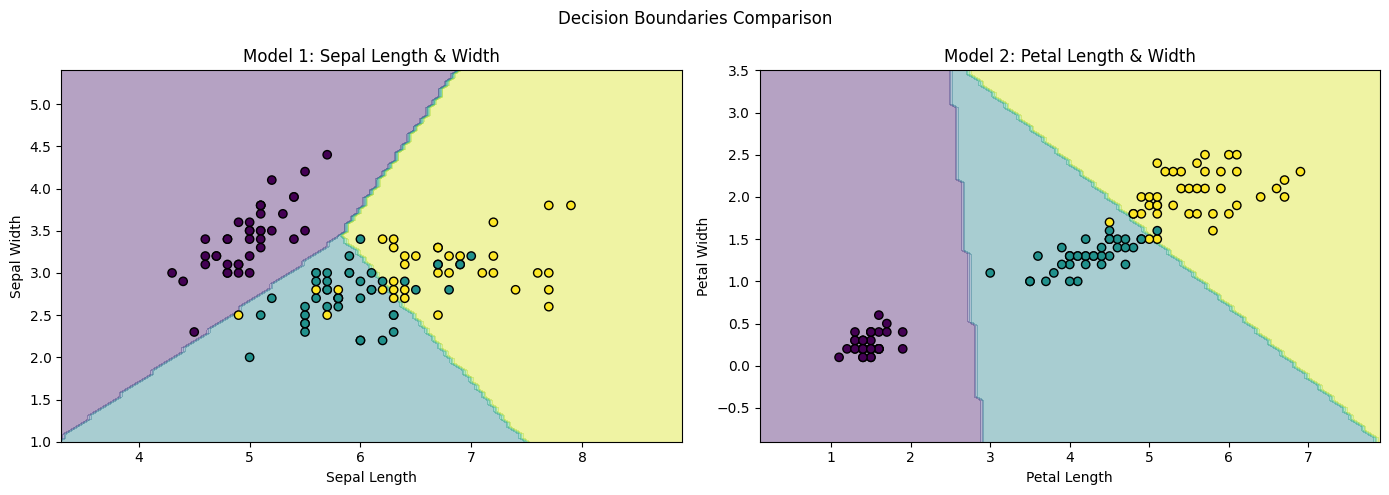

In [25]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model 1 - sepal features
DecisionBoundaryDisplay.from_estimator(
    model1, x1_train, ax=axes[0], response_method="predict", cmap="viridis", alpha=0.4
)
axes[0].scatter(x1_train[:, 0], x1_train[:, 1], c=y1_train, cmap="viridis", edgecolors="k")
axes[0].set_title("Model 1: Sepal Length & Width")
axes[0].set_xlabel("Sepal Length")
axes[0].set_ylabel("Sepal Width")

# Model 2 - petal features
DecisionBoundaryDisplay.from_estimator(
    model2, x2_train, ax=axes[1], response_method="predict", cmap="viridis", alpha=0.4
)
axes[1].scatter(x2_train[:, 0], x2_train[:, 1], c=y2_train, cmap="viridis", edgecolors="k")
axes[1].set_title("Model 2: Petal Length & Width")
axes[1].set_xlabel("Petal Length")
axes[1].set_ylabel("Petal Width")

plt.suptitle("Decision Boundaries Comparison")
plt.tight_layout()
plt.show()